#**ANALISIS SENTIMEN PENGGUNA TERHADAP WONDR BNI DI PLAY STORE**

#Instalasi Library


In [8]:
!pip install sastrawi
!pip install tensorflow
!pip install scikit-learn
!pip install pandas nltk wordcloud requests matplotlib seaborn
!pip install lightgbm xgboost catboost
!pip install dask[dataframe]

#Impor Library


In [9]:
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
import requests
import json
import string
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
import time
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
import pickle

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#Dataset

In [10]:
df = pd.read_csv('/content/hasil_scraping_smartfren.csv')
# Membaca file CSV dari folder content

df.head()

,content,score
0,"Jaringan Smartfren gak bangett, WhatsApp serin...",1
1,bener-bener provider paling busuk!!!!! jaringa...,1
2,"dulu bagus banget sinyalnya, awal bulan mei sa...",4
3,masih bisa dipake meski nggak ada kuota? kukir...,5
4,Anehnya terkadang jaringan suka lost beberapa ...,1


#Data Cleaning

In [11]:
clean_df = df.dropna()


In [12]:
clean_df = clean_df.drop_duplicates()


In [13]:
clean_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 149773 entries, 0 to 149999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   content  149773 non-null  object
 1   score    149773 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.4+ MB


In [14]:
clean_df.head()


,content,score
0,"Jaringan Smartfren gak bangett, WhatsApp serin...",1
1,bener-bener provider paling busuk!!!!! jaringa...,1
2,"dulu bagus banget sinyalnya, awal bulan mei sa...",4
3,masih bisa dipake meski nggak ada kuota? kukir...,5
4,Anehnya terkadang jaringan suka lost beberapa ...,1


#Pra-pemrosesan Teks (Text Preprocessing)

In [15]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join([word for word in text.split() if word.lower() not in ["mobile", "bni", "wondr", "bni mobile"]])
    text = text.strip(' ')
    return text

def casefoldingText(text):
    text = text.lower()
    return text

def tokenizingText(text):
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku','di','ya','loh','kah','deh'])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    stemmed_text = ' '.join(stemmed_words)
    return stemmed_text

def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

def fix_slangwords(text):
    words = text.split()
    fixed_words = []
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [16]:
url = 'https://raw.githubusercontent.com/aninanandah/datasetproject/main/slangwords.json'

response = requests.get(url)

if response.status_code == 200:
    try:
        slangwords = json.loads(response.text)
    except json.JSONDecodeError as e:
        print("Error decoding JSON:", e)
        print("Response content:", response.text)
else:
    print("Failed to fetch data from URL. Status code:", response.status_code)


In [17]:
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [18]:
clean_df.head()


,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,"Jaringan Smartfren gak bangett, WhatsApp serin...",1,Jaringan Smartfren gak bangett WhatsApp sering...,jaringan smartfren gak bangett whatsapp sering...,jaringan smartfren tidak bangett aplikasi pesa...,"[jaringan, smartfren, tidak, bangett, aplikasi...","[jaringan, smartfren, bangett, aplikasi, pesan...",jaringan smartfren bangett aplikasi pesan dela...
1,bener-bener provider paling busuk!!!!! jaringa...,1,benerbener provider paling busuk jaringan seti...,benerbener provider paling busuk jaringan seti...,benerbener provider paling busuk jaringan seti...,"[benerbener, provider, paling, busuk, jaringan...","[benerbener, provider, busuk, jaringan, memasu...",benerbener provider busuk jaringan memasuki so...
2,"dulu bagus banget sinyalnya, awal bulan mei sa...",4,dulu bagus banget sinyalnya awal bulan mei sam...,dulu bagus banget sinyalnya awal bulan mei sam...,dulu bagus banget sinyalnya awal bulan mei sam...,"[dulu, bagus, banget, sinyalnya, awal, bulan, ...","[bagus, banget, sinyalnya, mei, hilang, menit,...",bagus banget sinyalnya mei hilang menit jam si...
3,masih bisa dipake meski nggak ada kuota? kukir...,5,masih bisa dipake meski nggak ada kuota kukira...,masih bisa dipake meski nggak ada kuota kukira...,masih bisa dipake meski tidak ada kuota kukira...,"[masih, bisa, dipake, meski, tidak, ada, kuota...","[dipake, kuota, kukira, iklan, doang, beneran,...",dipake kuota kukira iklan doang beneran dipake...
4,Anehnya terkadang jaringan suka lost beberapa ...,1,Anehnya terkadang jaringan suka lost beberapa ...,anehnya terkadang jaringan suka lost beberapa ...,anehnya terkadang jaringan suka lost beberapa ...,"[anehnya, terkadang, jaringan, suka, lost, beb...","[anehnya, terkadang, jaringan, suka, lost, lan...",anehnya terkadang jaringan suka lost lancar ke...


#Pelabelan dan Ekstraksi Fitur

In [19]:
def load_lexicon(url):
    lexicon = dict()
    response = requests.get(url)

    if response.status_code == 200:
        lines = response.text.strip().split('\n')
        for line in lines:
            parts = line.split(',')
            word = ','.join(parts[:-1])
            score = parts[-1]
            lexicon[word.strip()] = int(score.strip())
    else:
        print(f"Failed to fetch lexicon data from {url}")

    return lexicon

positive_lexicon_url = 'https://raw.githubusercontent.com/aninanandah/datasetproject/main/LeksikonPositif.txt'
negative_lexicon_url = 'https://raw.githubusercontent.com/aninanandah/datasetproject/main/LeksikonNegatif.txt'

# Memuat leksikon positif dan negatif dari URL yang diberikan
lexicon_positive = load_lexicon(positive_lexicon_url)
lexicon_negative = load_lexicon(negative_lexicon_url)

In [20]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0

    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]

    for word in text:
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity = ''

    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity

In [21]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)


results = list(zip(*results))

clean_df['polarity_score'] = results[0]

clean_df['polarity'] = results[1]

print(clean_df['polarity'].value_counts())

polarity
negative    89540
positive    44994
neutral     15239
Name: count, dtype: int64


In [22]:
X = clean_df['text_akhir']
y = clean_df['polarity']

#Ekstraksi Fitur

In [23]:
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8, ngram_range=(1, 1))
X_tfidf = tfidf.fit_transform(X)

In [24]:
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
features_df

,aktif,ampun,aneh,anjing,aplikasi,aplikasinya,app,bagus,banget,bantuan,...,turun,uang,ulang,unlimited,update,utama,voucher,whatsapp,wifi,youtube
0,0.0,0.0,0.0,0.0,0.124072,0.0,0.0,0.000000,0.000000,0.126185,...,0.0,0.0,0.0,0.153061,0.0,0.0,0.0,0.0,0.0,0.210114
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.117901,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.166928,0.156235,0.156001,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.231107,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.359633
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149768,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
149769,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
149770,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000
149771,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.405318,0.000000,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000


#**Data Visualization**

#Presentase Polaritas

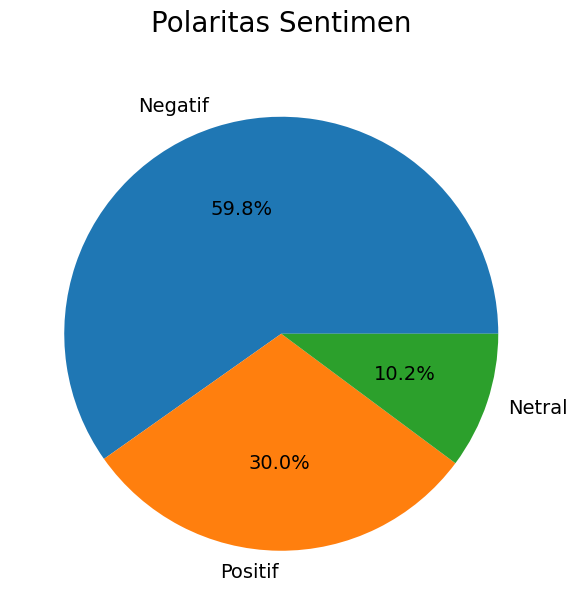

In [25]:
fig, ax = plt.subplots(figsize=(7, 8))
sizes = [count for count in clean_df['polarity'].value_counts()]
#labels = list(clean_df['polarity'].value_counts().index)  # Mengambil nama kategori polaritas sentimen
labels = ['Negatif', 'Positif', 'Netral']
explode = (0, 0, 0)
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Polaritas Sentimen', fontsize=20, pad=22)
plt.show()

#Word Cloud

In [26]:
positive_review = clean_df[clean_df['polarity'] == 'positive']
positive_review = positive_review[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
positive_review = positive_review.sort_values(by='polarity_score', ascending=False)
positive_review = positive_review.reset_index(drop=True)
positive_review.index += 1

In [27]:
negative_review = clean_df[clean_df['polarity'] == 'negative']
negative_review = negative_review[['text_akhir', 'polarity_score', 'polarity','text_stopword']]
negative_review = negative_review.sort_values(by='polarity_score', ascending=False)
negative_review = negative_review.reset_index(drop=True)
negative_review.index += 1

In [28]:
neutral_review = clean_df[clean_df['polarity'] == 'neutral']
neutral_review = neutral_review[['text_akhir', 'polarity_score', 'polarity','text_stopword']]
neutral_review = neutral_review.sort_values(by='polarity_score', ascending=False)
neutral_review = neutral_review.reset_index(drop=True)
neutral_review.index += 1

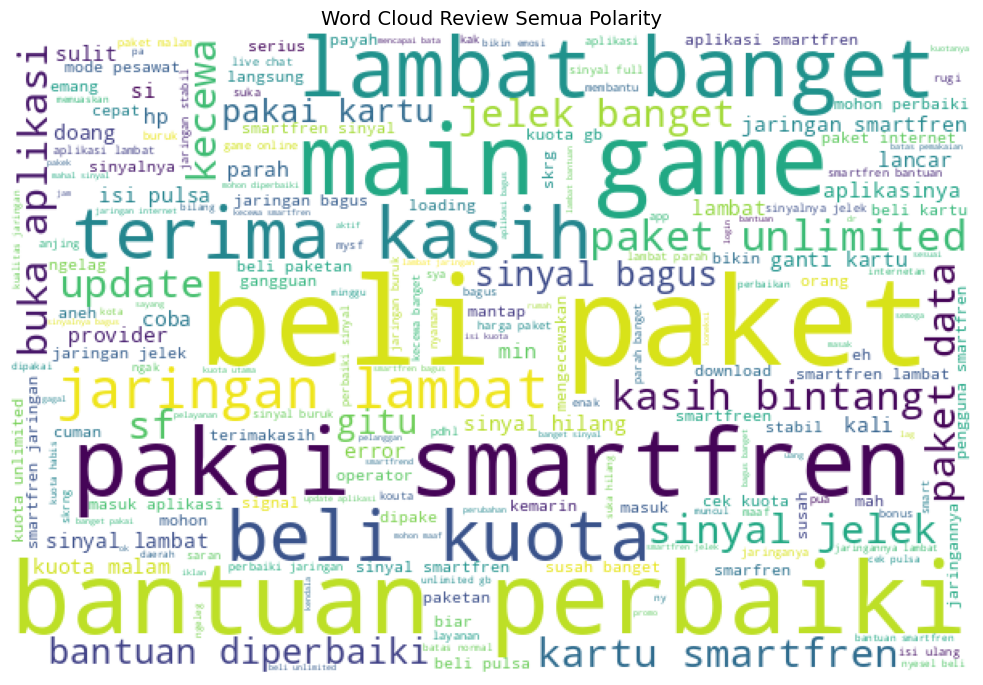

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Menggabungkan kata secara cepat (anti-lemot)
list_words = ' '.join(clean_df['text_stopword'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x)))

# 2. Membuat dan menampilkan Word Cloud
wordcloud = WordCloud(width=600, height=400, background_color='white').generate(list_words)
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Word Cloud Review Semua Polarity', fontsize=14)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

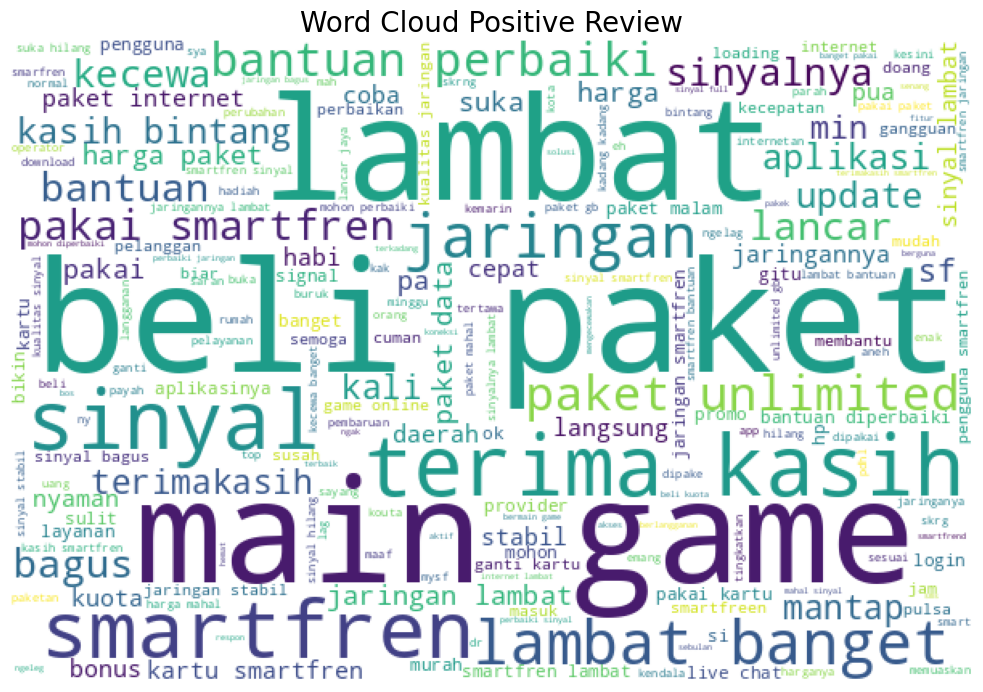

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Menggabungkan kata review POSITIF secara instan tanpa loop lambat
list_words = ' '.join(positive_review['text_stopword'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x)))

# 2. Membuat dan menampilkan Word Cloud khusus Review Positif
wordcloud = WordCloud(width=600, height=400, background_color='white').generate(list_words)
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Word Cloud Positive Review', fontsize=20)
ax.grid(False)
ax.imshow(wordcloud)
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

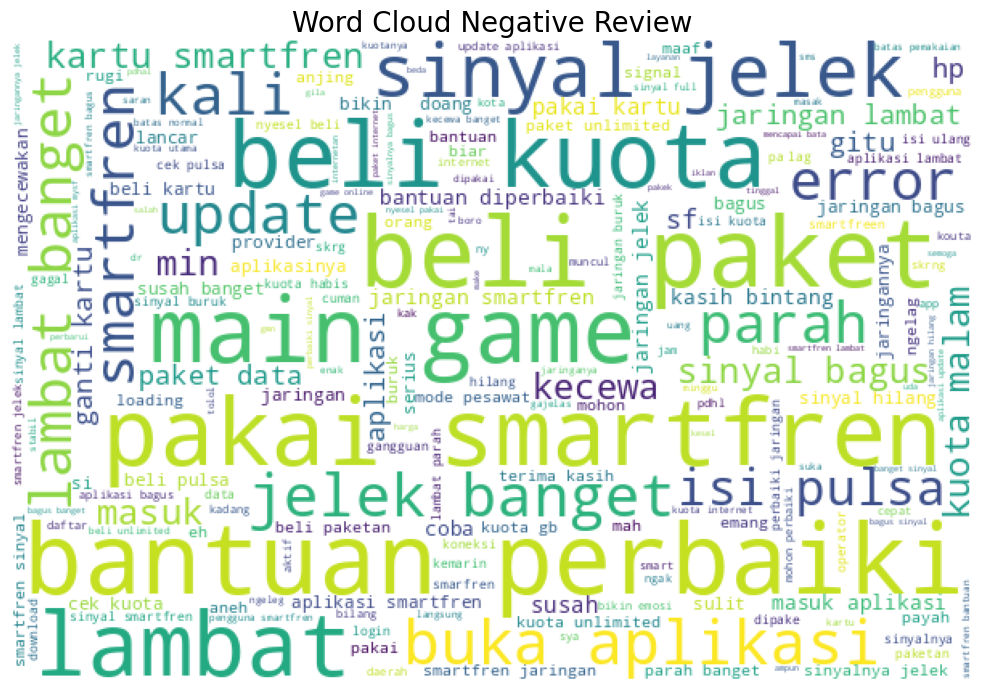

In [31]:
# --- NEW OPTIMIZED CODE BLOCK ---
# Optimization to combine words (fast vectorization with join)
# Replaces the slow nested loop from image_643f35.png
list_words = ' '.join(negative_review['text_stopword'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x)))

# Standard visualization code from here:
wordcloud = WordCloud(width=600, height=400, background_color='white').generate(list_words)
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Word Cloud Negative Review', fontsize=20)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()
# --- End New Code Block ---

#Distribusi Kelas

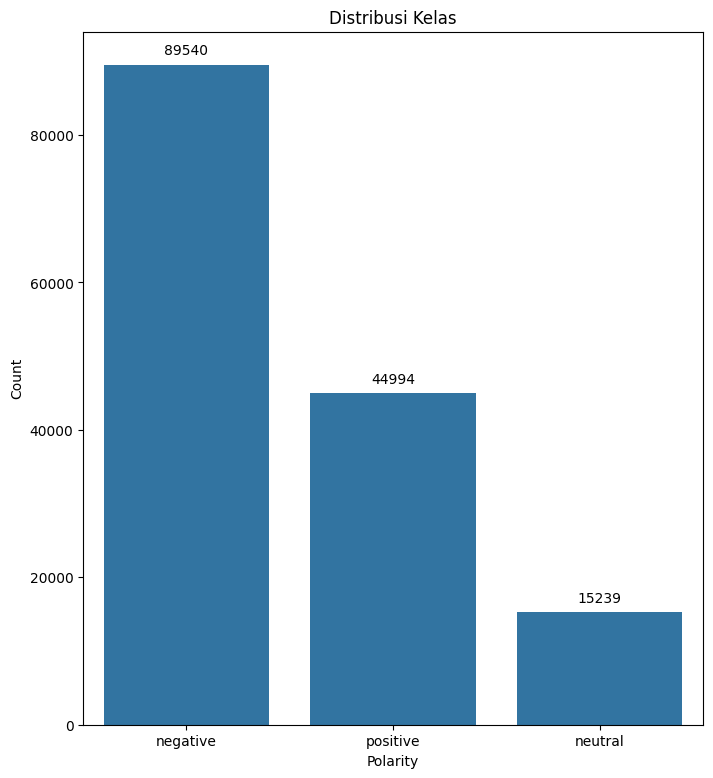

In [32]:
# Mengatur ukuran gambar plot
plt.figure(figsize=(8, 9))

# Membuat plot count menggunakan seaborn untuk variabel 'polarity' dari dataframe 'clean_df'
class_dist_plot = sns.countplot(x='polarity', data=clean_df)

# Menetapkan judul plot
plt.title('Distribusi Kelas')

# Menetapkan label sumbu x
plt.xlabel('Polarity')

# Menetapkan label sumbu y
plt.ylabel('Count')

# Menambahkan label angka untuk setiap bar pada plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center',
                             xytext=(0, 10),
                             textcoords='offset points')

# Menampilkan plot
plt.show()

#Pemodelan

#Data Splitting

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=50)

#LogisticRegression

In [34]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8249011000016692
Logistic Regression - accuracy_test: 0.8203304957436154


#XGBoost

In [35]:
# Mengonversi sparse matrix ke array
X_train_array = X_train.toarray()
X_test_array = X_test.toarray()

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Membuat objek model XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42)

# Melatih model XGBoost pada data pelatihan
start_time = time.time()
xgb.fit(X_train_array, y_train_encoded)
execution_time = time.time() - start_time

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_xgb = xgb.predict(X_train_array)
y_pred_test_xgb = xgb.predict(X_test_array)

# Evaluasi akurasi model XGBoost pada data pelatihan
accuracy_train_xgb = accuracy_score(y_pred_train_xgb, y_train_encoded)

# Evaluasi akurasi model XGBoost pada data uji
accuracy_test_xgb = accuracy_score(y_pred_test_xgb, y_test_encoded)

# Menampilkan akurasi dan waktu eksekusi
print('XGBoost - accuracy_train:', accuracy_train_xgb)
print('XGBoost - accuracy_test:', accuracy_test_xgb)
print('XGBoost - execution_time:', execution_time, 'seconds')

XGBoost - accuracy_train: 0.8337895808643109
XGBoost - accuracy_test: 0.8084126189283926
XGBoost - execution_time: 34.19791269302368 seconds


#CatBoost

In [36]:
from catboost import CatBoostClassifier
import time

# Membuat objek model CatBoost
cat_model = CatBoostClassifier(n_estimators=100, random_state=42, verbose=0)

# Melatih model CatBoost pada data pelatihan
start_time = time.time()
cat_model.fit(X_train.toarray(), y_train)
execution_time = time.time() - start_time

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_cat = cat_model.predict(X_train.toarray())
y_pred_test_cat = cat_model.predict(X_test.toarray())

# Evaluasi akurasi model CatBoost pada data pelatihan
accuracy_train_cat = accuracy_score(y_pred_train_cat, y_train)

# Evaluasi akurasi model CatBoost pada data uji
accuracy_test_cat = accuracy_score(y_pred_test_cat, y_test)

# Menampilkan akurasi dan waktu eksekusi
print('CatBoost - accuracy_train:', accuracy_train_cat)
print('CatBoost - accuracy_test:', accuracy_test_cat)
print('CatBoost - execution_time:', execution_time, 'seconds')


CatBoost - accuracy_train: 0.8185664925136457
CatBoost - accuracy_test: 0.8091804373226507
CatBoost - execution_time: 39.784284353256226 seconds


# SVM

In [37]:
import time  # <--- Tambahkan ini agar Colab mengenal fungsi penghitung waktu
from sklearn.svm import LinearSVC

# 1. Membuat objek model LinearSVC yang jauh lebih cepat untuk data besar
svm = LinearSVC(random_state=42)

# 2. Melatih model (langsung masukkan matriks X_train)
start_time = time.time()
svm.fit(X_train, y_train)
execution_time = time.time() - start_time

# 3. Prediksi sentimen
y_pred_train_svm = svm.predict(X_train)
y_pred_test_svm = svm.predict(X_test)

# 4. Evaluasi akurasi model SVM pada data pelatihan
accuracy_train_svm = accuracy_score(y_pred_train_svm, y_train)

# 5. Evaluasi akurasi model SVM pada data uji
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_test)

# 6. Menampilkan akurasi dan waktu eksekusi
print('SVM - accuracy_train:', accuracy_train_svm)
print('SVM - accuracy_test:', accuracy_test_svm)
print('SVM - execution_time:', execution_time, 'seconds')

SVM - accuracy_train: 0.8156287035336928
SVM - accuracy_test: 0.8111834418294108
SVM - execution_time: 1.7183606624603271 seconds


#Perbandingan Akurasi Model

In [38]:
# Membuat DataFrame untuk hasil akurasi
results_df = pd.DataFrame({
    'Model': ['Logistic Regression','Support Vector Machine','Extreme Gradient Boosting','Categorical Boosting'],
    'Accuracy Train': [accuracy_train_lr, accuracy_train_svm, accuracy_train_xgb, accuracy_train_cat],
    'Accuracy Test': [accuracy_test_lr, accuracy_test_svm, accuracy_test_xgb, accuracy_test_cat]
})

# Menampilkan hanya kolom "Accuracy Test"
accuracy_test_only = results_df[['Model','Accuracy Train', 'Accuracy Test']]

# Mengurutkan DataFrame berdasarkan kolom "Accuracy Test" dari tertinggi ke terendah
accuracy_test_sorted = accuracy_test_only.sort_values(by='Accuracy Test', ascending=False)

# Menampilkan DataFrame yang telah diurutkan
print(accuracy_test_sorted)

                       Model  Accuracy Train  Accuracy Test
0        Logistic Regression        0.824901       0.820330
1     Support Vector Machine        0.815629       0.811183
3       Categorical Boosting        0.818566       0.809180
2  Extreme Gradient Boosting        0.833790       0.808413


#Kesimpulan

In [39]:
# Simpan model SVM
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

In [40]:
# Simpan TfidfVectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [41]:
!pip freeze > requirements.txt